In this notebook we visualize our data. This file is organized in two parts:

1. Text Metadata, where we plot informations such as evolution of Lovecraft bibliography, distribution over magazines, etc.

2. Text Statistics, where we plot informations regarding the content of the stories themselves, such as their numerical representation, Fourier transforms, complexity, entropy, etc.

# 0. Setup

In [1]:
# Libraries

# General
import numpy as np                      # imports the Numpy library for numerical tools
import pandas as pd                     # imports the Pandas library for data manipulation and analysis

# Plotting Options
from matplotlib import pyplot as plt                           # imports the Pyplot module from the Matplotlib library for plotting
plt.rcParams['text.usetex'] = True                             # enables LaTeX rendering for text in plots
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  # LaTeX preamble

# File management
import pathlib as Path                  # imports path tools from Pathlib for working with file paths
import os                               # imports the OS library for interacting with the operating system
os.chdir('..')                          # changes to the parent directory

# tools for text processing
from tools import text_tools

In [2]:
biblio = text_tools.bibliography()  # defines a bibliography object
print( biblio.files )               # lists the files in the directory

['mountains_of_madness.txt', 'nyarlathotep.txt', 'moon_bog.txt', 'book.txt', 'other_gods.txt', 'randolph_carter.txt', 'picture_house.txt', 'cool_air.txt', 'alchemist.txt', 'nameless.txt', 'festival.txt', 'reanimator.txt', 'arthur_jermyn.txt', 'dunwich.txt', 'doorstep.txt', 'ulthar.txt', 'haunter.txt', 'crawling_chaos.txt', 'from_beyond.txt', 'dagon.txt', 'pharoahs.txt', 'juan_romero.txt', 'colour_out_of_space.txt', 'clergyman.txt', 'celephais.txt', 'iranon.txt', 'poetry_of_gods.txt', 'descendent.txt', 'shunned_house.txt', 'beyond_wall_of_sleep.txt', 'redhook.txt', 'outsider.txt', 'dreams_in_the_witch.txt', 'charles_dexter_ward.txt', 'pickman.txt', 'old_folk.txt', 'he.txt', 'memory.txt', 'martins_beach.txt', 'polaris.txt', 'hypnos.txt', 'ex_oblivione.txt', 'medusas_coil.txt', 'street.txt', 'erich_zann.txt', 'rats_walls.txt', 'kadath.txt', 'tree.txt', 'innsmouth.txt', 'gates_of_silver_key.txt', 'azathoth.txt', 'white_ship.txt', 'terrible_old_man.txt', 'high_house_mist.txt', 'silver_key.t

# 1. Text Metada

In [ ]:
# Usando as informações da tabela de metadados, plotar:

# 1. Série temporal para a produção de estórias: Ano x Nº de estórias
# 2. Gráfico de pizza para as revistas: Revista x Nº de estórias
# 3. Gráfico de Pizza para a classificação: Classificação x Nº de estórias

In [3]:
biblio.df_texts.head()  # displays the first few rows of the DataFrame containing the text metadata

,text,file,sentence_count,word_count,vocabulary,character_count
0,mountains_of_madness,mountains_of_madness.txt,1396,40413,8897,245865
1,nyarlathotep,nyarlathotep.txt,55,1130,600,6718
2,moon_bog,moon_bog.txt,109,3413,1213,18595
3,book,book.txt,47,1146,565,6398
4,other_gods,other_gods.txt,81,1897,720,10325


Text(0.5, 1.0, 'Word count distribution')

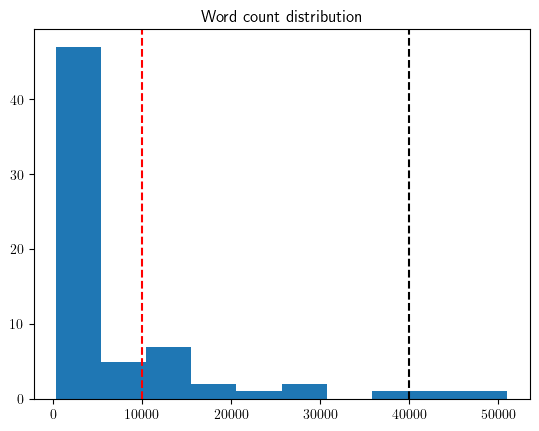

In [4]:
# word count histogram
plt.hist( biblio.df_texts['word_count'])  # creates a histogram of the word counts of the texts
plt.axvline( x = 1e4, color='red', linestyle='--', label='Novella' )
plt.axvline( x = 4e4, color='black', linestyle='--', label='Novel' )
plt.title('Word count distribution')

Text(0.5, 1.0, 'Sentence count distribution')

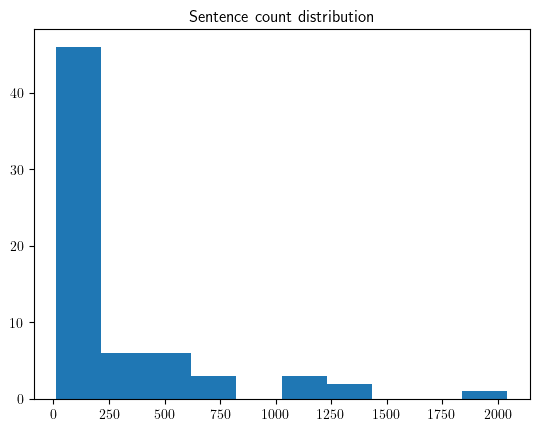

In [5]:
# sentence count histogram
plt.hist( biblio.df_texts['sentence_count'])  # creates a histogram of the sentence counts of the texts
plt.title('Sentence count distribution')

Text(0.5, 1.0, 'Vocabulary size distribution')

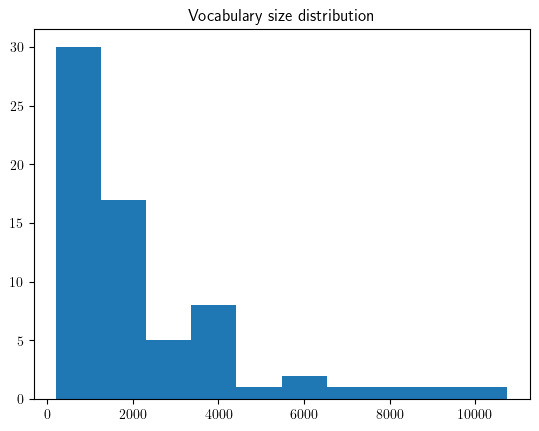

In [6]:
# vocabulary histogram
plt.hist( biblio.df_texts['vocabulary'])  # creates a histogram of the vocabulary sizes of the texts
plt.title('Vocabulary size distribution')

Text(0.5, 1.0, 'Character count distribution')

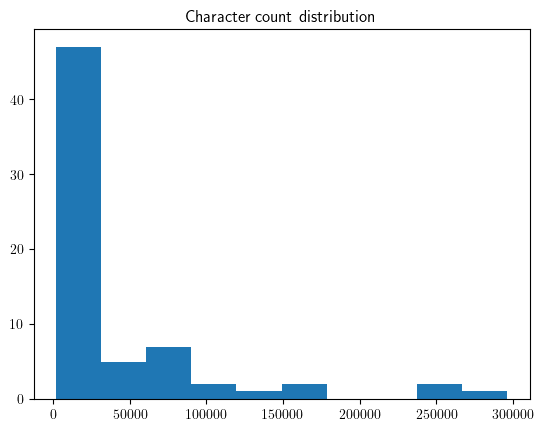

In [7]:
# character count histogram
plt.hist( biblio.df_texts['character_count'])  # creates a histogram of the character counts of the texts
plt.title('Character count distribution')

Text(0.5, 1.0, 'Vocabulary to word count ratio distribution')

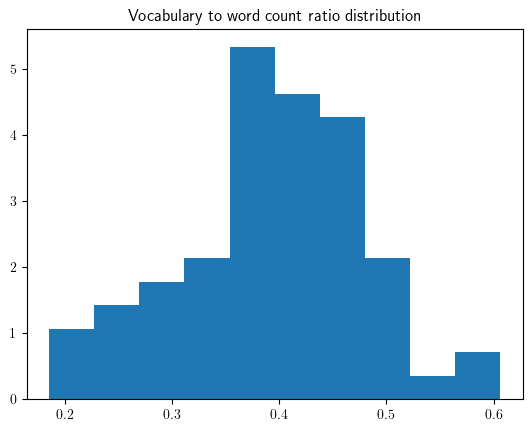

In [8]:
# vocabulary to word count ratio histogram

# vocabulary to word count
vocab_to_word = biblio.df_texts['vocabulary']/biblio.df_texts['word_count']

plt.hist( vocab_to_word, density=True )  # creates a histogram of the vocabulary sizes of the texts
plt.title('Vocabulary to word count ratio distribution')

(np.float64(486.80876335872915), np.float64(-1.4970099393267242), np.float64(0.0038845457066956184))


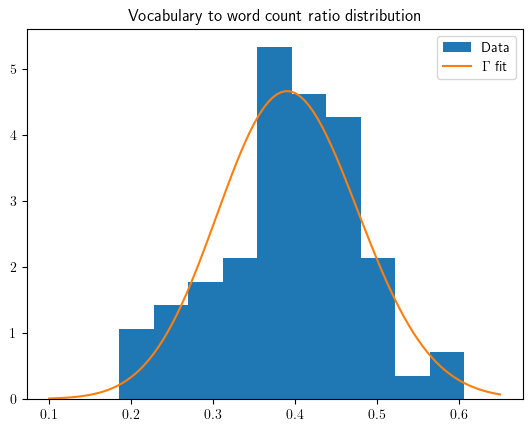

In [20]:
# vocabulary to word count ratio histogram

# vocabulary to word count
vocab_to_word = biblio.df_texts['vocabulary']/biblio.df_texts['word_count']

# gamma distribution fit (tried gamma due to assymetry)
from scipy.stats import gamma
params = gamma.fit( vocab_to_word )  # fits a gamma distribution to the vocabulary to

print(params)

x = np.linspace(0.1, 0.65, 100)
gamma_fit = gamma.pdf( x, *params )

plt.hist( vocab_to_word, density=True, label='Data' )  # creates a histogram of the vocabulary sizes of the texts
plt.plot( x, gamma_fit, label=r'$\Gamma$ fit')  # plots the fitted gamma distribution
plt.title('Vocabulary to word count ratio distribution')
plt.legend()
plt.show()

# 2. Text Statistics